In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
d = np.load('u_allt_backward.npy', 'r') #_backward

NameError: name 'np' is not defined

In [ ]:
d.shape

In [ ]:
t = 999

abcn = 0
M = 1
b = abcn + M

plt.figure(figsize=(10, 5))
vmin, vmax = np.percentile(d[t].squeeze()[b:-b,b:-b], [0.5, 99.5])
plt.imshow(d[t].squeeze()[b:-b,b:-b], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar()
plt.title(f'u_allt[{t}, 0]')
plt.show()

In [ ]:
models = ['Vp', 'Vs', 'Density']
model_no = 1
vp_ad = np.load(f'{models[model_no]}_grad_ad.npy')
vp_cuda = np.load(f'{models[model_no]}_grad_cuda.npy')
assert vp_ad.shape == vp_cuda.shape

In [ ]:
# vp_ad/= np.max(np.abs(vp_ad))
# vp_cuda/= np.max(np.abs(vp_cuda))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
vmin, vmax = np.percentile(vp_ad, [2, 98])
axes[0].imshow(vp_ad, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('AD')
vmin, vmax = np.percentile(vp_cuda, [2, 98])
axes[1].imshow(vp_cuda, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('CUDA')
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(figsize=(8, 4))
trace_no = 10#vp_ad.shape[1]//2
t_ad = vp_ad[:, trace_no].copy()
t_ad/=np.abs(t_ad).max()
t_cuda = vp_cuda[:, trace_no].copy()
t_cuda/=np.abs(t_cuda).max()
plt.plot(t_ad, label='AD')
plt.plot(t_cuda, label='CUDA')
plt.legend()
plt.show()

In [ ]:
dw_record = np.load('record_deepwave.npy')
vmin, vmax = np.percentile(dw_record, [0.5, 99.5])
plt.imshow(dw_record.squeeze().T, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar()
plt.title(f'record_deepwave')
plt.show()

In [ ]:
u_last_sweep = np.load('/ibex/user/wangs0j/geophyai/test/cuda/u_last.npy')
vx, vz = u_last_sweep[:2]

fig, axes = plt.subplots(1, 2, figsize=(8,3))
vmin, vmax = np.percentile(vz, [0.5, 99.5])
im = axes[0].imshow(vz[0].squeeze().T, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('Vz')
vmin, vmax = np.percentile(vx, [0.5, 99.5])
im = axes[1].imshow(vx[0].squeeze().T, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('Vx')
plt.tight_layout()
plt.savefig('wavefield_sweep.png', dpi=300)
plt.show()

In [ ]:
rec_cuda = np.load('record_CUDA.npy').squeeze().T
rec_torch = np.load('record_PyTorch.npy').squeeze()
print(np.allclose(rec_cuda, rec_torch, atol=1e-5))
print(rec_cuda.shape, rec_torch.shape)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(rec_cuda, 'r', label='CUDA')
ax.plot(rec_torch, 'b', label='PyTorch')
ax.legend()
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(rec_cuda-rec_torch, 'r', label='residual')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
vmin, vmax = np.percentile(rec_torch, [0.5, 99.5])
axes[0].imshow(rec_cuda, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('CUDA')
axes[1].imshow(rec_torch, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('PyTorch')
plt.tight_layout()
plt.show()

# Check boundary

In [ ]:
pml = np.load('azh.npy').squeeze()
end_point = 22
print(pml[:end_point][-1])
print(len(pml[:end_point]))
plt.scatter(np.arange(end_point), pml[:end_point])
plt.show()

# Check adjoint pytorch

In [ ]:
adj_pytorch = np.load('/ibex/user/wangs0j/geophyai/test/cuda/adjoint_wavefields_torch.npy', 'r')
adj_cuda = np.load('/data/tmp/u_allt_backward.npy', 'r')
print(adj_pytorch.shape, adj_cuda.shape)

In [ ]:
308-296

In [ ]:
vx, vz, sxx, szz, sxz = adj_pytorch[:,0], adj_pytorch[:,1], adj_pytorch[:,2], adj_pytorch[:,3], adj_pytorch[:,4]
vx_cuda, vz_cuda, sxx_cuda, szz_cuda, sxz_cuda = adj_cuda[0], adj_cuda[1], adj_cuda[2], adj_cuda[3], adj_cuda[4]

In [ ]:
vx_cuda.shape

In [ ]:
show_t = 500
b = 20
bcuda = 26
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, (field, field_cuda, name) in enumerate(zip([vx, vz, sxx, szz, sxz], [vx_cuda, vz_cuda, sxx_cuda, szz_cuda, sxz_cuda], ['Vx', 'Vz', 'Sxx', 'Szz', 'Sxz'])):
    vmin, vmax = np.percentile(field[show_t].squeeze()[b:-b,b:-b], [2, 98])
    ax = axes[0,i].imshow(field[show_t].squeeze()[b:-b,b:-b], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(ax, ax=axes[0,i])
    axes[0,i].set_title(name)

    scale = -1 if 'S' in name else 1
    vmin, vmax = np.percentile(scale*field_cuda[show_t].squeeze()[bcuda:-bcuda,bcuda:-bcuda], [2, 98])
    ax = axes[1,i].imshow(scale*field_cuda[show_t].squeeze()[bcuda:-bcuda,bcuda:-bcuda], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(ax, ax=axes[1,i])
    axes[1,i].set_title(name + ' CUDA')

plt.tight_layout()
plt.show()

# Check adjoint and forward data

In [30]:
u_adjoint = np.load('/data/tmp/u_adoint.npy', 'r')
u_forward = np.load('/data/tmp/u_forward.npy', 'r')

In [31]:
abcn = 20
M = 1
b = abcn + M

In [32]:
print(u_adjoint[..., b:-b, b:-b].shape, u_forward[..., b:-b, b:-b].shape)

(1, 1, 118, 103, 103) (1000, 1, 1, 94, 52, 52)


In [35]:
# vz_adjoint = u_adjoint[1].squeeze()
# vz_forward = u_forward.squeeze()

In [36]:
show_t = 10
show_vz_adjoint = vz_adjoint[show_t][..., b:-b, b:-b]
show_vz_forward = vz_forward[show_t][..., b:-b, b:-b]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
vmin, vmax = np.percentile(show_vz_adjoint, [2, 98])
ax = axes[0].imshow(show_vz_adjoint, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar(ax, ax=axes[0])
axes[0].set_title('Vz Adjoint')

vmin, vmax = np.percentile(show_vz_forward, [0.5, 99.5])
ax = axes[1].imshow(show_vz_forward, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar(ax, ax=axes[1])
axes[1].set_title('Vz Forward')

plt.tight_layout()
plt.show()

NameError: name 'vz_adjoint' is not defined

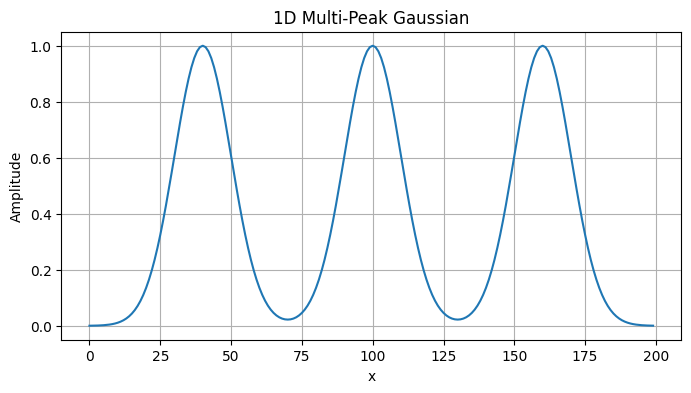

In [39]:
def generate_1d_gaussian(n, centers, sigma, normalize=True):
    """Generate a 1D multi-peak Gaussian field.

    Args:
        n (int): Length of the output field along x direction
        centers (list): List of center positions for the Gaussian peaks
        sigma (int/float): Standard deviation of the Gaussian peaks
        normalize (bool, optional): Whether to normalize the field to maximum value of 1. Defaults to True.

    Returns:
        np.ndarry: The generated 1D multi-peak Gaussian field.
    """
    
    x = np.arange(n)
    field = np.zeros(n)
    
    for x0 in centers:
        field += np.exp(-((x - x0)**2) / (2 * sigma**2))
    
    if normalize:
        field /= field.max()
        

    return field

n = 200
centers = [40, 100, 160]
sigma = 10

field = generate_1d_gaussian(n, centers, sigma)

plt.figure(figsize=(8,4))
plt.plot(field)
plt.title("1D Multi-Peak Gaussian")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [340]:
ones = np.ones((100, n))
plt.imshow(ones*field[None, :], aspect='auto', cmap='viridis')
plt.colorbar()
plt.show()

NameError: name 'n' is not defined

# 3D ELASTIC

In [340]:
import numpy as np
import matplotlib.pyplot as plt

In [343]:
b = 1
adjoint = np.load('/data/tmp/u_forward.npy', 'r')[0]#[..., b:-b, b:-b, b:-b]
print(adjoint.max(), adjoint.min())
print(adjoint.shape)

1.6755539e-09 -1.6754065e-09
(1, 1, 47, 47, 47)


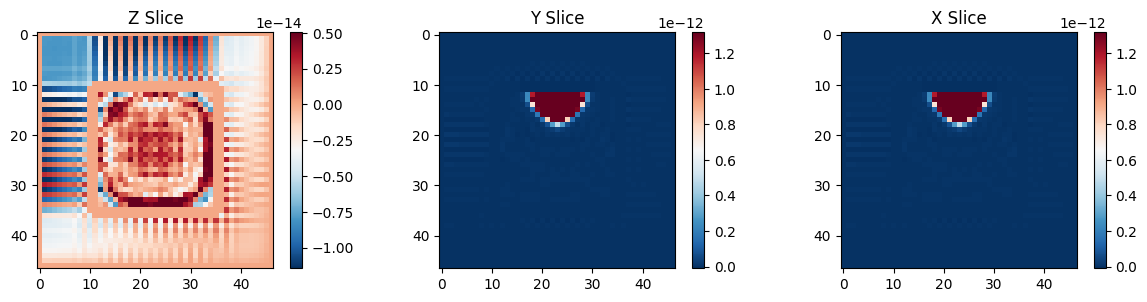

In [344]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
nz, ny, nx = adjoint.shape[-3:]
slicez = adjoint.squeeze()[nz//2]
slicey = adjoint.squeeze()[:,ny//2]
slicex = adjoint.squeeze()[...,nx//2]

vmin, vmax = np.percentile(slicez, [2, 98])
ax = axes[0].imshow(slicez, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(ax, ax=axes[0])
axes[0].set_title('Z Slice')
vmin, vmax = np.percentile(slicey, [2, 98])
ax = axes[1].imshow(slicey, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(ax, ax=axes[1])
axes[1].set_title('Y Slice')
vmin, vmax = np.percentile(slicex, [2, 98])
ax = axes[2].imshow(slicex, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(ax, ax=axes[2])
axes[2].set_title('X Slice')
plt.tight_layout()
plt.show()

# Check 2d boundary saving

In [367]:
import numpy as np
import matplotlib.pyplot as plt

forward = np.load('/data/tmp/u_forward.npy', 'r')
print(forward.max(), forward.min(), forward.shape)

3.562896 -1.7383287 (3000, 1, 1, 314, 620)


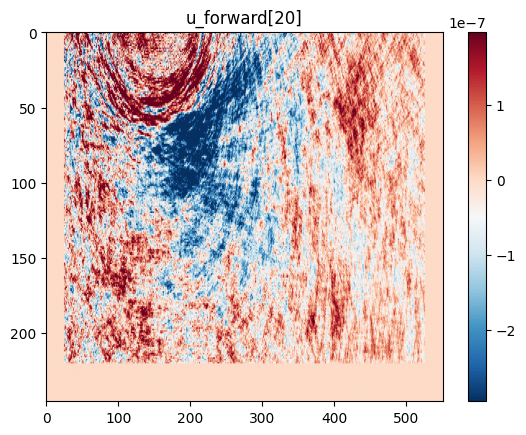

In [368]:
show_t = 20
abcn = 30
so = 8
b = abcn + so//2

show_d = forward[show_t].squeeze()[b:-b,b:-b]
vmin, vmax = np.percentile(forward[show_t], [2, 98])
plt.imshow(show_d, cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar()
plt.title(f'u_forward[{show_t}]')
plt.show()

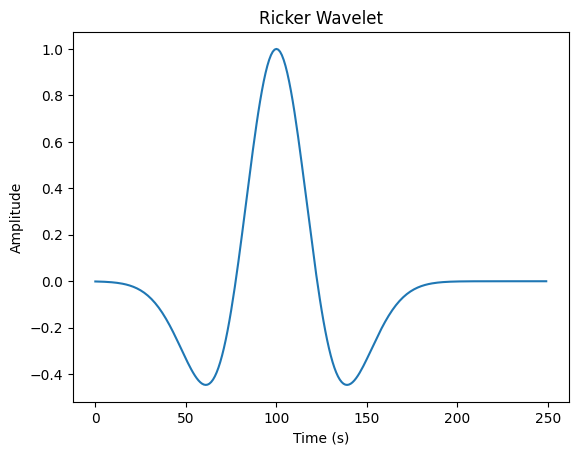

In [192]:
def ricker(t, fm):
    pi2 = np.pi * 2
    wave = (1 - 0.5 * (pi2 * fm * t) ** 2) * np.exp(-0.25 * (pi2 * fm * t) ** 2)
    return wave#.to(torch.float32)

nt = 3000
dt = 0.002
delay = 0.2
fm = 5.0
t = np.arange(nt) * dt - delay
wave = ricker(t, fm=fm).astype(np.float32)
plt.plot(wave[:250])
plt.title('Ricker Wavelet')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

15
model padding left: [0.39355004 0.39355004 0.39355004 0.39355004 0.39355004 0.46251744
 0.5335268  0.60406595 0.6712935  0.7322183  0.78391445 0.82375264
 0.8496204  0.86010814 0.        ]
model padding right: [0.         0.86010814 0.8496204  0.82375264 0.78391445 0.7322183
 0.6712935  0.60406595 0.5335268  0.46251744 0.39355004 0.39355004
 0.39355004 0.39355004 0.39355004]


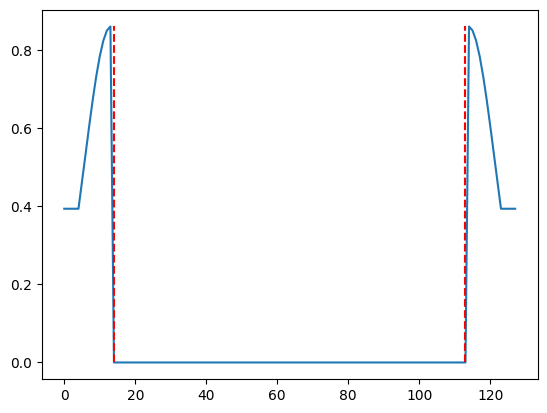

In [216]:
import numpy as np
import matplotlib.pyplot as plt
az = np.load('ax.npy').squeeze()
print(len(az[:b+1]))
abcn = 10
so = 8
b = abcn + so//2
print('model padding left:', az[:b+1])
print('model padding right:', az[-b-1:])
plt.plot(az)
plt.vlines(x=b, ymin=az.min(), ymax=az.max(), color='r', linestyle='--', label='Boundary Start')
plt.vlines(x=len(az)-b-1, ymin=az.min(), ymax=az.max(), color='r', linestyle='--', label='Boundary End')
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

grad_vp_cuda = np.load('grad_CUDA_vp.npy')
grad_vs_cuda = np.load('grad_CUDA_vs.npy')
grad_rho_cuda = np.load('grad_CUDA_rho.npy')
grad_vp_pytorch = np.load('grad_PyTorch_vp.npy')
grad_vs_pytorch = np.load('grad_PyTorch_vs.npy')
grad_rho_pytorch = np.load('grad_PyTorch_rho.npy')

In [2]:
nz, ny, nx = grad_vp_cuda.shape

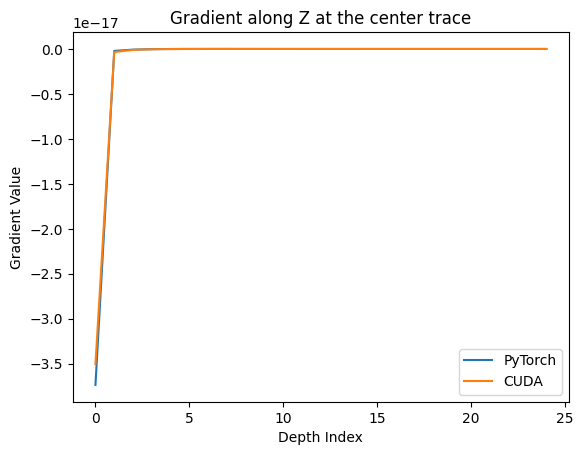

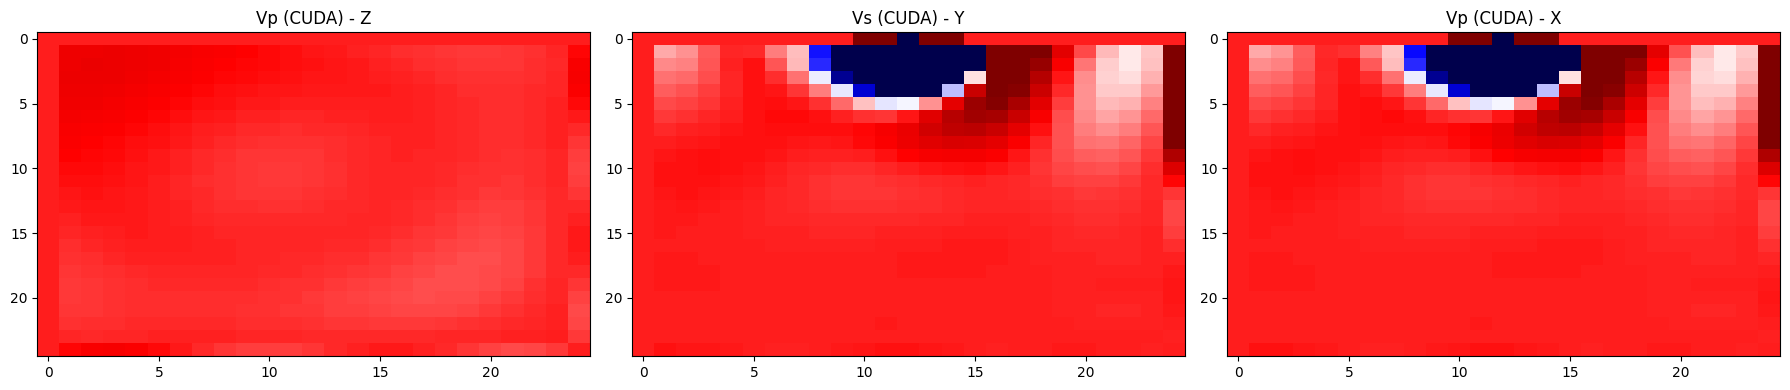

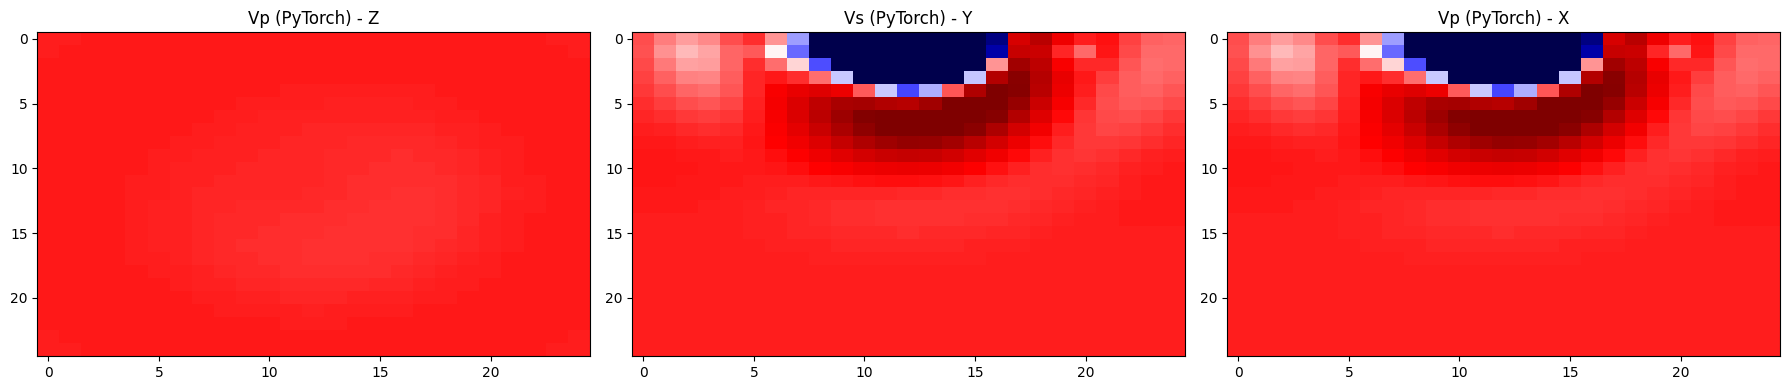

In [4]:
plt.plot(grad_vp_pytorch[...,nx//2][:,ny//2], label='PyTorch')
plt.plot(grad_vp_cuda[...,nx//2][:,ny//2], label='CUDA')
plt.legend()
plt.title('Gradient along Z at the center trace')
plt.xlabel('Depth Index')
plt.ylabel('Gradient Value')
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
vmin, vmax = np.percentile(grad_vp_pytorch, [1, 99])
axes[0].imshow(grad_vp_cuda[nz//2, :, :], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('Vp (CUDA) - Z')
axes[1].imshow(grad_vp_cuda[:,ny//2, :], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('Vs (CUDA) - Y')
axes[2].imshow(grad_vp_cuda[...,nx//2], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[2].set_title('Vp (CUDA) - X')
plt.tight_layout()
plt.savefig('grad_CUDA_vp.png', dpi=300)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(grad_vp_pytorch[nz//2, :, :], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('Vp (PyTorch) - Z')
axes[1].imshow(grad_vp_pytorch[:,ny//2, :], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('Vs (PyTorch) - Y')
axes[2].imshow(grad_vp_pytorch[...,nx//2], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[2].set_title('Vp (PyTorch) - X')
plt.tight_layout()
plt.savefig('grad_PyTorch_vp.png', dpi=300)
plt.show()